# Part I — Min-Variance Portfolio (EUR)

Group project for SAAM. We got EUR region with scope 1+2.
Rolling 10yr window, annual rebalancing, long-only.
OOS period: Jan 2014 to Dec 2025.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

## Data loading

All the Datastream exports live in `Data_2026/`. The static file has the region
tags we need to filter on.

In [3]:
ddir = 'Data_2026/'

static = pd.read_excel(ddir + 'Static_2025.xlsx')
ri_m_raw = pd.read_excel(ddir + 'DS_RI_T_USD_M_2025.xlsx', sheet_name='RI')
mv_m_raw = pd.read_excel(ddir + 'DS_MV_T_USD_M_2025.xlsx', sheet_name='MV')
ri_y_raw = pd.read_excel(ddir + 'DS_RI_T_USD_Y_2025.xlsx', sheet_name='RI')
mv_y_raw = pd.read_excel(ddir + 'DS_MV_T_USD_Y_2025.xlsx', sheet_name='MV')
s1_raw = pd.read_excel(ddir + 'DS_CO2_SCOPE_1_Y_2025.xlsx', sheet_name='Scope1')
s2_raw = pd.read_excel(ddir + 'DS_CO2_SCOPE_2_Y_2025.xlsx', sheet_name='Scope2')
rev_raw = pd.read_excel(ddir + 'DS_REV_Y_2025.xlsx', sheet_name='REV')
rf_raw  = pd.read_excel(ddir + 'Risk_Free_Rate_2025.xlsx',
                         sheet_name='F-F_Research_Data_Factors')

print(f'Static: {static.shape}')
print(f'RI monthly: {ri_m_raw.shape}')

Static: (2545, 4)
RI monthly: (2609, 316)


## Cleaning the Datastream dump

DS is messy, some rows have `ER:` error codes, columns are either timestamps or ints
depending on the file, and there are ISINs that don't match anything in our static list.
The below cleans all of that.

In [4]:
eur_isins = set(static.loc[static['Region'] == 'EUR', 'ISIN'])
print(f'{len(eur_isins)} EUR ISINs')

def scrub_ds(df, valid):
    """Strip DS junk and keep only our EUR ISINs."""
    df = df.dropna(subset=['ISIN']).copy()
    df = df[~df['ISIN'].astype(str).str.contains('ER:', na=False)]
    df = df[df['ISIN'].isin(valid)]
    names = df.set_index('ISIN')['NAME']
    dcols = [c for c in df.columns if c not in ('NAME', 'ISIN') and c is not None]
    out = df.set_index('ISIN')[dcols].apply(pd.to_numeric, errors='coerce')
    # normalise column types — DS gives timestamps for monthly, ints for yearly
    out.columns = [pd.Timestamp(c) if hasattr(c, 'year') and not isinstance(c, (int, np.integer))
                   else c for c in out.columns]
    return out, names

ri_m, _names = scrub_ds(ri_m_raw, eur_isins)
mv_m, _      = scrub_ds(mv_m_raw, eur_isins)
ri_y, _      = scrub_ds(ri_y_raw, eur_isins)
mv_y, _      = scrub_ds(mv_y_raw, eur_isins)
s1, _        = scrub_ds(s1_raw, eur_isins)
s2, _        = scrub_ds(s2_raw, eur_isins)
rev, _       = scrub_ds(rev_raw, eur_isins)

isin2name = _names.to_dict()
print(f'{ri_m.shape[0]} EUR firms after cleanup')

633 EUR ISINs
633 EUR firms after cleanup


In [5]:
# grab valid date columns
mo = sorted([c for c in ri_m.columns
             if isinstance(c, pd.Timestamp)
             and pd.Timestamp('2000-01-01') <= c <= pd.Timestamp('2025-12-31')])
yr_cols = sorted([c for c in ri_y.columns if isinstance(c, (int, np.integer))])

# trim everything
ri_m = ri_m[mo]
mv_m = mv_m[[c for c in mo if c in mv_m.columns]]
ri_y = ri_y[[c for c in yr_cols if c in ri_y.columns]]
mv_y = mv_y[[c for c in yr_cols if c in mv_y.columns]]
s1 = s1[[c for c in yr_cols if c in s1.columns]]
s2 = s2[[c for c in yr_cols if c in s2.columns]]
rev = rev[[c for c in yr_cols if c in rev.columns]]

print(f'{mo[0]:%Y-%m} to {mo[-1]:%Y-%m}, {len(mo)} monthly obs')

2000-01 to 2025-12, 312 monthly obs


In [6]:
def months_of(yr):
    return [d for d in mo if d.year == yr]

def window_for(yr, length=10):
    # 10yr rolling window ending Dec of yr
    y0 = yr - length + 1
    return [d for d in mo if (y0, 1) <= (d.year, d.month) <= (yr, 12)]

# sanity
w13 = window_for(2013)
assert len(w13) == 120, f'expected 120 months, got {len(w13)}'
print(f'Window 2013: {w13[0]:%Y-%m} to {w13[-1]:%Y-%m} ({len(w13)}m)')

Window 2013: 2004-01 to 2013-12 (120m)


## Risk-free rate

FF data is annualised in %. Compound to monthly.

In [ ]:
rf_raw.columns = ['YYYYMM', 'RF_pct']
rf_raw = rf_raw.dropna(subset=['YYYYMM'])
rf_raw['dt'] = pd.to_datetime(rf_raw['YYYYMM'].astype(int).astype(str), format='%Y%m')
rf_raw['dt'] += pd.offsets.MonthEnd(0)

# RF_pct is the MONTHLY rate expressed in percent (Fama-French convention).
# Just convert percent -> decimal. Annualisation happens later in perf()
# via rf_ann = 12 * mean(rf_monthly), to match how portfolio returns are annualised.
rf_m = (rf_raw.set_index('dt')['RF_pct'] / 100).squeeze()
rf_m.name = 'RF'
print(f'RF: {rf_m.index.min():%Y-%m} to {rf_m.index.max():%Y-%m}')

# --- Sanity check: annualised avg rf in our sample window should be in a
# plausible T-bill range (~0.5%-5% over 2014-2025). If not, the conversion
# above is wrong. This catches the common mistake of compounding monthly
# rates as if they were annual.
_rf_ann_check = rf_m.loc['2014-01-01':'2025-12-31'].mean() * 12
assert 0.005 < _rf_ann_check < 0.05, (
    f'Annualised avg rf = {_rf_ann_check:.4%} - outside plausible range. '
    f'Check whether RF_pct is monthly (correct) or annual (needs ^(1/12)).'
)
print(f'Sanity: annualised avg rf over 2014-2025 = {_rf_ann_check*100:.4f}%')


## Price cleaning

DS rounds RI to 2 decimals, so values below 0.50 can be garbage (0.00 after rounding).
These create infinite returns. Also need to forward-fill gaps *within* a stock's life
(not before IPO or after delisting) and detect delistings.

In [8]:
PRICE_FLOOR = 0.50

# zap penny prices
n_zapped = ((ri_m > 0) & (ri_m < PRICE_FLOOR)).sum().sum()
ri_m[ri_m < PRICE_FLOOR] = np.nan
print(f'Killed {n_zapped} prices below {PRICE_FLOOR}')

# forward-fill internal gaps only (between first and last valid price)
nans_pre = ri_m.isna().sum().sum()
for isin in ri_m.index:
    row = ri_m.loc[isin]
    fv, lv = row.first_valid_index(), row.last_valid_index()
    if fv is None:
        continue
    idx = list(row.index)
    i0, i1 = idx.index(fv), idx.index(lv)
    ri_m.loc[isin, :] = row  # no-op but keeps things explicit
    filled = row.iloc[i0:i1+1].ffill()
    ri_m.loc[isin, filled.index] = filled
nans_post = ri_m.isna().sum().sum()
print(f'Forward-filled {nans_pre - nans_post} internal gaps')

Killed 687 prices below 0.5
Forward-filled 147 internal gaps


In [9]:
# if last valid price is before end of sample → probably delisted
cutoff = pd.Timestamp('2025-12-31')
delisted = {}
for isin in ri_m.index:
    lv = ri_m.loc[isin].last_valid_index()
    if lv is not None and isinstance(lv, pd.Timestamp) and lv < cutoff:
        delisted[isin] = lv
print(f'{len(delisted)} stocks look delisted')

66 stocks look delisted


In [10]:
ret = ri_m.pct_change(axis=1)

# at the month after delisting, return = -100% (total loss)
for isin, ddate in delisted.items():
    if ddate not in mo:
        continue
    ix = mo.index(ddate)
    if ix + 1 < len(mo):
        ret.at[isin, mo[ix + 1]] = -1.0
        # blank out everything after — stock is dead
        for j in range(ix + 2, len(mo)):
            if mo[j] in ret.columns:
                ret.at[isin, mo[j]] = np.nan

ret = ret.iloc[:, 1:]  # first col is NaN (no prior price)
print(f'{(ret == -1.0).sum().sum()} delisting events injected')

66 delisting events injected


In [11]:
# per instructions: carry forward missing annual carbon/revenue data
s1 = s1.ffill(axis=1)
s2 = s2.ffill(axis=1)
rev = rev.ffill(axis=1)

## Universe construction

Each Dec we pick the investable firms: need a valid price, enough return history (>=36mo),
not too stale (<30% zero returns), and carbon data for both scopes.

The carbon filter is what really bites in the early years — lots of EUR firms didn't
start reporting until 2010-2012.

In [12]:
MIN_OBS = 36       # need at least 3 years of monthly returns
STALE_CUT = 0.30   # >30% zero returns = illiquid, skip

def get_universe(yr):
    dec = [d for d in mo if d.year == yr and d.month == 12]
    if not dec:
        return []
    dec = dec[0]

    wcols = [d for d in window_for(yr) if d in ret.columns]
    R = ret.reindex(columns=wcols)

    out = []
    for isin in ri_m.index:
        # valid Dec price
        if pd.isna(ri_m.at[isin, dec]):
            continue
        if isin not in R.index:
            continue

        r = R.loc[isin]
        nok = r.notna().sum()
        if nok < MIN_OBS:
            continue

        # stale check
        nz = ((r == 0) | (r.abs() < 1e-10)).sum()
        if nz / nok > STALE_CUT:
            continue

        # need scope 1+2 for this year
        has1 = yr in s1.columns and isin in s1.index and pd.notna(s1.at[isin, yr])
        has2 = yr in s2.columns and isin in s2.index and pd.notna(s2.at[isin, yr])
        if not (has1 and has2):
            continue

        out.append(isin)
    return out

univ = {}
for y in range(2013, 2025):
    univ[y] = get_universe(y)
    print(f'{y}: {len(univ[y]):3d} firms')

2013: 470 firms
2014: 488 firms
2015: 506 firms
2016: 513 firms
2017: 526 firms
2018: 547 firms
2019: 574 firms
2020: 593 firms
2021: 602 firms
2022: 592 firms
2023: 577 firms
2024: 565 firms


## Covariance estimation

Pairwise-complete correlations (because stocks have different listing dates) combined
with ML variances, then shrink toward a constant-correlation target. The shrinkage
formula is OAS-style, similar to what we covered in the lectures on robust estimation.

I tried plain Ledoit-Wolf (identity target) first but the constant-correlation target
gave much better out-of-sample vol. The eigenvalue floor at the end is a safety net
for the optimizer, without it SLSQP sometimes chokes on near-singular matrices.

In [13]:
LW_FLOOR = 0.01  # don't let shrinkage go below 1%

def cov_shrunk(isins, wdates):
    cols = [d for d in wdates if d in ret.columns]
    R = ret.loc[isins, cols].values   # (N, T)
    N = len(isins)
    ok = ~np.isnan(R)
    mu = np.nanmean(R, axis=1)

    # ML variance per stock
    dm = R - mu[:, None]
    dm_z = np.where(ok, dm, 0.0)
    nobs = ok.sum(axis=1)
    var = np.where(nobs > 1, np.sum(dm_z**2, axis=1) / nobs, 0.0)

    # --- pairwise correlations ---
    R_z = np.where(ok, R, 0.0)
    ok_f = ok.astype(float)

    cnt = ok_f @ ok_f.T              # joint obs count per pair
    cnt_s = np.maximum(cnt, 1)       # avoid /0

    si = R_z @ ok_f.T                # sum of stock i when both valid
    sj = ok_f @ R_z.T
    mi = si / cnt_s                  # conditional pairwise means
    mj = sj / cnt_s

    cross = R_z @ R_z.T
    cov_pw = cross / cnt_s - mi * mj

    # normalise to correlations
    sqi = (R_z**2) @ ok_f.T
    vi = np.maximum(sqi / cnt_s - mi**2, 0.0)
    sqj = ok_f @ (R_z**2).T
    vj = np.maximum(sqj / cnt_s - mj**2, 0.0)

    den = np.sqrt(vi * vj)
    rho = np.where(den > 1e-20, cov_pw / den, 0.0)

    # reconstruct cov = rho * sig_i * sig_j
    sig = np.sqrt(var)
    S = rho * np.outer(sig, sig)
    np.fill_diagonal(S, var)
    S = (S + S.T) / 2

    # --- constant-correlation target ---
    sd = np.sqrt(np.diag(S))
    sd_safe = np.where(sd > 1e-20, sd, 1e-20)
    C = S / np.outer(sd_safe, sd_safe)
    np.fill_diagonal(C, 1.0)
    C = np.clip(C, -1, 1)
    rho_avg = (C.sum() - N) / (N * (N - 1))

    F = rho_avg * np.outer(sig, sig)
    np.fill_diagonal(F, var)

    # OAS intensity
    trS = np.trace(S)
    trS2 = np.trace(S @ S)
    T_eff = max(np.median(cnt[np.triu_indices(N, k=1)]), 2)

    num = (1 - 2/N) * trS2 + trS**2
    denom = (T_eff + 1 - 2/N) * (trS2 - trS**2 / N)
    if abs(denom) < 1e-20:
        delta = 0.5
    else:
        delta = max(min(num / denom, 1.0), LW_FLOOR)

    Sig = delta * F + (1 - delta) * S

    # eigenvalue clip → guaranteed PSD
    evals, evecs = np.linalg.eigh(Sig)
    if evals[0] < 1e-10:
        evals = np.maximum(evals, 1e-10)
        Sig = evecs @ np.diag(evals) @ evecs.T
        Sig = (Sig + Sig.T) / 2

    return mu, Sig

## Min-var solver

Long-only, fully invested. I warm-start from the previous year's drifted weights
because starting from equal-weight is slow when N > 300.

In [14]:
_drifted = {}  # will hold end-of-year drifted weights for warm starts

def solve_mv(Sigma, isins, yr):
    N = Sigma.shape[0]

    # try to warm-start from last year's drifted portfolio
    if yr in _drifted:
        w0 = np.array([_drifted[yr].get(s, 0.0) for s in isins])
        w0 = w0 / w0.sum() if w0.sum() > 0 else np.ones(N) / N
    else:
        w0 = np.ones(N) / N

    res = minimize(
        lambda w: float(w @ Sigma @ w),
        w0,
        jac=lambda w: 2.0 * (Sigma @ w),
        method='SLSQP',
        bounds=[(0, None)] * N,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
        options={'ftol': 1e-10, 'maxiter': 1000},
    )
    if not res.success:
        print(f'  WARNING yr={yr}: {res.message}')
    return res.x

## Backtest

For each year: estimate cov → solve → track through 12 OOS months with weight drift.

During the OOS year, if a stock disappears (NaN return) but it was alive last month,
that's a delisting → -100%. If it was never alive (leading NaN), treat as 0 return.

In [15]:
def oos_returns(firms, months_oos):
    R = ret.loc[firms].reindex(columns=months_oos).copy()
    for isin in firms:
        dead = False
        for t in months_oos:
            if dead:
                R.at[isin, t] = np.nan
                continue
            if pd.isna(R.at[isin, t]):
                tidx = mo.index(t)
                prev = mo[tidx-1] if tidx > 0 else None
                had_px = (prev is not None and prev in ri_m.columns
                          and isin in ri_m.index and pd.notna(ri_m.at[isin, prev]))
                if had_px:
                    R.at[isin, t] = -1.0
                    dead = True
                else:
                    R.at[isin, t] = 0.0
    return R.fillna(0.0)

# ---------- main loop ----------
wts = {}     # yr → Series of optimal weights
pr_mv = {}   # yr+1 → Series of monthly portfolio returns

for yr in range(2013, 2025):
    firms = univ[yr]
    N = len(firms)
    if N == 0:
        print(f'{yr}: empty, skip')
        continue

    mu_hat, Sig = cov_shrunk(firms, window_for(yr))
    w = solve_mv(Sig, firms, yr)
    wts[yr] = pd.Series(w, index=firms)

    ea_vol = np.sqrt(float(w @ Sig @ w) * 12) * 100  # annualised

    nxt = months_of(yr + 1)
    Rn = oos_returns(firms, nxt)
    ww = w.copy()
    rets_list = []
    for t in nxt:
        rt = Rn[t].values
        rp = float(ww @ rt)
        rets_list.append(rp)
        ww = ww * (1 + rt) / max(1 + rp, 1e-12)

    pr_mv[yr+1] = pd.Series(rets_list, index=nxt)
    _drifted[yr+1] = dict(zip(firms, ww))

    nnz = (w > 1e-6).sum()
    print(f'{yr}: {N:3d} firms | {nnz:3d} active | vol {ea_vol:.2f}%')

rp_mv = pd.concat(pr_mv).droplevel(0).sort_index()
rp_mv.index = pd.DatetimeIndex(rp_mv.index)

2013: 470 firms |  23 active | vol 9.79%
2014: 488 firms |  21 active | vol 9.39%
2015: 506 firms |  21 active | vol 9.88%
2016: 513 firms |  21 active | vol 10.18%
2017: 526 firms |  21 active | vol 10.32%
2018: 547 firms |  30 active | vol 9.93%
2019: 574 firms |  26 active | vol 9.00%
2020: 593 firms |  27 active | vol 9.05%
2021: 602 firms |  36 active | vol 8.92%
2022: 592 firms |  31 active | vol 9.43%
2023: 577 firms |  26 active | vol 9.48%
2024: 565 firms |  22 active | vol 9.37%


## Value-weighted benchmark

Weight by lagged market cap each month. Same universe as min-var.

In [16]:
pr_vw = {}
for yr in range(2013, 2025):
    firms = univ[yr]
    nxt = months_of(yr + 1)
    Rn = oos_returns(firms, nxt)
    mrets = []
    for t in nxt:
        tidx = mo.index(t) if t in mo else None
        if tidx is None or tidx == 0:
            mrets.append(np.nan)
            continue
        prev = mo[tidx - 1]
        cap = mv_m.loc[firms, prev].fillna(0) if prev in mv_m.columns else pd.Series(0.0, index=firms)
        tot = cap.sum()
        if tot <= 0:
            mrets.append(0.0)
            continue
        mrets.append(float((cap / tot).values @ Rn[t].values))
    pr_vw[yr+1] = pd.Series(mrets, index=nxt)

rp_vw = pd.concat(pr_vw).droplevel(0).sort_index()
rp_vw.index = pd.DatetimeIndex(rp_vw.index)

## Performance comparison

In [17]:
def perf(rp, rf, label):
    rp = rp.dropna()
    rfr = rf.reindex(rp.index).ffill().fillna(0)
    T = len(rp)
    mu_a = 12 * rp.mean()
    mu_g = (1 + rp).prod() ** (12/T) - 1
    vol  = rp.std() * np.sqrt(12)
    sr   = (mu_a - 12*rfr.mean()) / vol
    cum  = (1 + rp).cumprod()
    mdd  = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'Portfolio': label,
            'Ann Ret Arith (%)': round(mu_a*100, 2),
            'Ann Ret Geom (%)':  round(mu_g*100, 2),
            'Ann Vol (%)':       round(vol*100, 2),
            'Sharpe':            round(sr, 3),
            'Min Mo (%)':        round(rp.min()*100, 2),
            'Max Mo (%)':        round(rp.max()*100, 2),
            'Max DD (%)':        round(mdd*100, 2)}

stats_df = pd.DataFrame([
    perf(rp_vw, rf_m, 'Value-Weighted'),
    perf(rp_mv, rf_m, 'Min-Variance'),
]).set_index('Portfolio')
stats_df

,Ann Ret Arith (%),Ann Ret Geom (%),Ann Vol (%),Sharpe,Min Mo (%),Max Mo (%),Max DD (%)
Portfolio,,,,,,,
Value-Weighted,8.19,7.16,15.87,0.507,-15.34,18.27,-28.17
Min-Variance,4.67,3.84,13.39,0.338,-12.01,12.79,-23.36


In [18]:
# quick checks
for yr, w in wts.items():
    assert abs(w.sum() - 1.0) < 1e-6, f'{yr}: weights dont sum to 1'
    assert (w >= -1e-8).all(), f'{yr}: negative weight'
print('Weights OK')

n_exp = sum(len(months_of(y+1)) for y in range(2013, 2025))
print(f'MV: {len(rp_mv.dropna())}mo (expect {n_exp}), VW: {len(rp_vw.dropna())}mo')
assert rp_mv.isna().sum() == 0 and rp_vw.isna().sum() == 0, 'NaN!'
print('No NaN — fine')

Weights OK
MV: 144mo (expect 144), VW: 144mo
No NaN — fine


## Top 10 holdings

Checking a few years to make sure the optimizer isn't putting everything into one stock.

In [19]:
for yr in [2013, 2018, 2024]:
    if yr not in wts:
        continue
    w = wts[yr].sort_values(ascending=False)
    nnz = (w > 1e-6).sum()
    print(f'\nDec {yr}: {nnz} non-zero / {len(w)} total')
    for rk, (isin, wt) in enumerate(w.head(10).items(), 1):
        cty = static.loc[static['ISIN'] == isin, 'Country'].values
        cty = cty[0] if len(cty) else '??'
        print(f'  {rk:2d}. {isin2name.get(isin, isin):<40s} {cty:>3s}  {wt*100:6.2f}%')


Dec 2013: 23 non-zero / 470 total
   1. TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1    IL   14.97%
   2. VALIANT 'R'                               CH   11.98%
   3. SWISSCOM 'R'                              CH   11.29%
   4. COLOPLAST B                               DK    8.20%
   5. DIGNITY DEAD - DELIST.25/05/23            GB    7.36%
   6. DE LA RUE ORD DEAD - DELIST.03/07/25      GB    6.68%
   7. ASTRAZENECA                               GB    6.57%
   8. UNITED UTILITIES GROUP                    GB    5.49%
   9. CHUBB                                     CH    4.87%
  10. AON CLASS A                               IE    4.32%

Dec 2018: 30 non-zero / 547 total
   1. AON CLASS A                               IE   12.87%
   2. VALIANT 'R'                               CH   11.65%
   3. SWISSCOM 'R'                              CH    8.86%
   4. COMPASS GROUP                             GB    7.47%
   5. TELECOM PLUS                              GB    6.62%
   6. DECHRA PHARMACEUTICALS D

## Charts

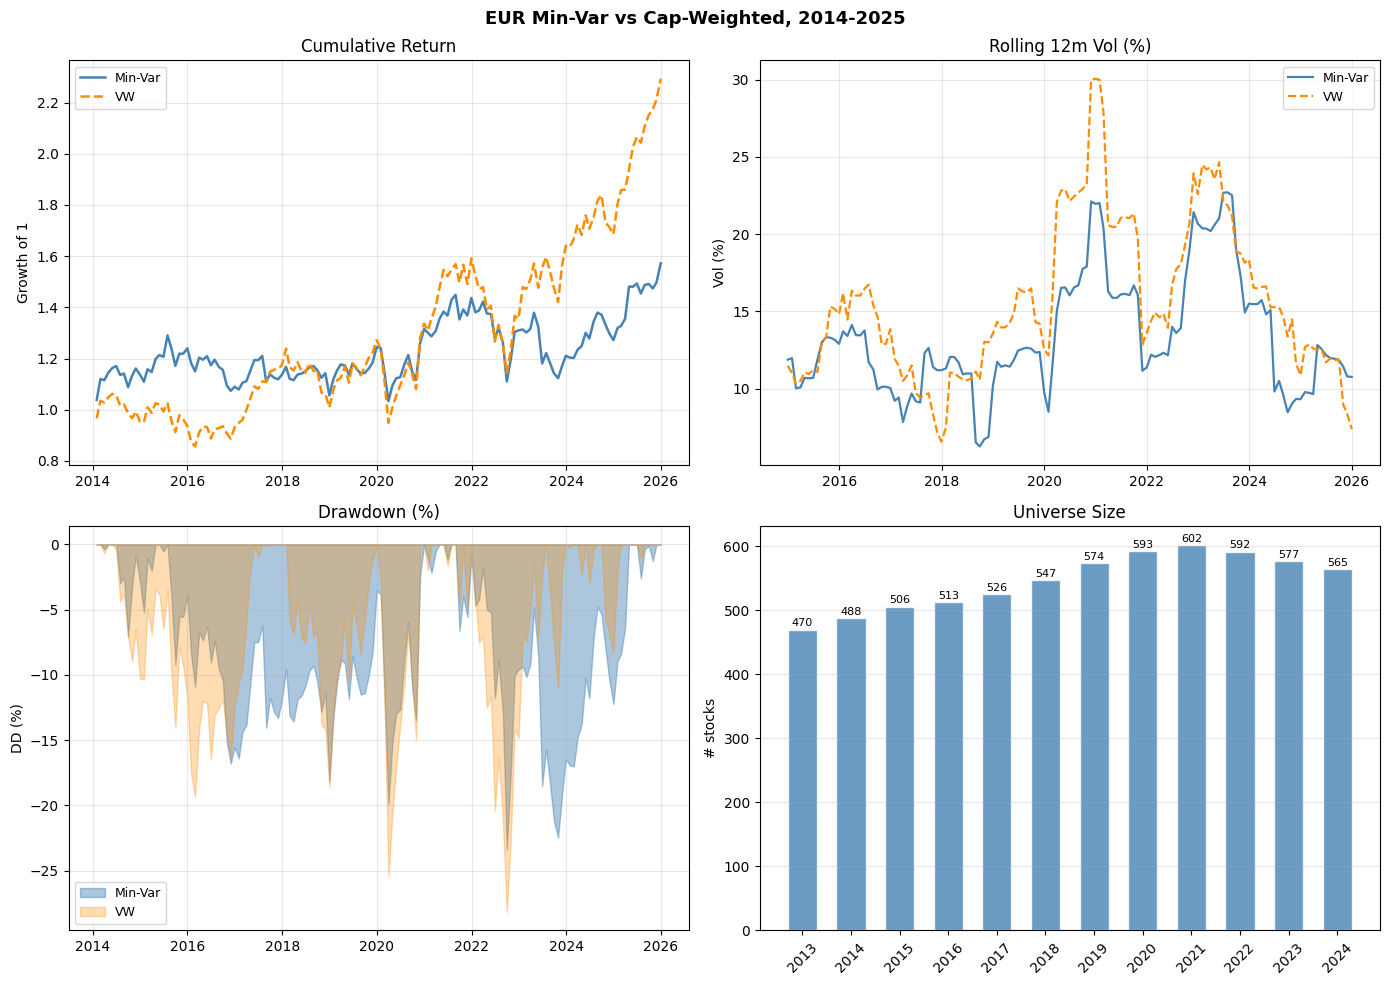

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EUR Min-Var vs Cap-Weighted, 2014-2025', fontsize=13, fontweight='bold')

C1, C2 = 'steelblue', 'darkorange'

# cumulative
a = ax[0,0]
cm = (1 + rp_mv.dropna()).cumprod()
cv = (1 + rp_vw.dropna()).cumprod()
a.plot(cm.index, cm.values, color=C1, lw=1.8, label='Min-Var')
a.plot(cv.index, cv.values, color=C2, lw=1.8, ls='--', label='VW')
a.set_title('Cumulative Return')
a.set_ylabel('Growth of 1')
a.legend(fontsize=9); a.grid(alpha=0.3)
a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
a.xaxis.set_major_locator(mdates.YearLocator(2))

# rolling vol
a = ax[0,1]
a.plot(rp_mv.index, rp_mv.rolling(12).std()*np.sqrt(12)*100,
       color=C1, lw=1.6, label='Min-Var')
a.plot(rp_vw.index, rp_vw.rolling(12).std()*np.sqrt(12)*100,
       color=C2, lw=1.6, ls='--', label='VW')
a.set_title('Rolling 12m Vol (%)')
a.set_ylabel('Vol (%)')
a.legend(fontsize=9); a.grid(alpha=0.3)
a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
a.xaxis.set_major_locator(mdates.YearLocator(2))

# drawdown
a = ax[1,0]
for rp, c, lbl, alph in [(rp_mv, C1, 'Min-Var', 0.45), (rp_vw, C2, 'VW', 0.30)]:
    cum = (1 + rp.dropna()).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax() * 100
    a.fill_between(dd.index, dd.values, 0, alpha=alph, color=c, label=lbl)
a.set_title('Drawdown (%)')
a.set_ylabel('DD (%)')
a.legend(fontsize=9); a.grid(alpha=0.3)
a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
a.xaxis.set_major_locator(mdates.YearLocator(2))

# universe size
a = ax[1,1]
yrs = sorted(univ.keys())
szs = [len(univ[y]) for y in yrs]
a.bar(yrs, szs, color=C1, alpha=0.8, edgecolor='white', width=0.6)
a.set_title('Universe Size')
a.set_ylabel('# stocks')
a.set_xticks(yrs); a.set_xticklabels(yrs, rotation=45)
a.grid(axis='y', alpha=0.3)
for y, s in zip(yrs, szs):
    a.text(y, s+5, str(s), ha='center', fontsize=8)

plt.tight_layout()
out_dir = 'Output_2026/'
for ext in ('pdf', 'png'):
    plt.savefig(f'{out_dir}SAAM_Part1_EUR_figures.{ext}', dpi=150, bbox_inches='tight')
plt.show()

## Template + extended results

In [21]:
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XlImage

out_dir = 'Output_2026/'
tpl = 'Data_2026/Template_for_Part_I-SAAM.xlsx'

def tpl_stats(rp, rf):
    rp = rp.dropna()
    rfr = rf.reindex(rp.index).ffill().fillna(0)
    T = len(rp)
    mu_a = 12 * rp.mean()
    mu_g = (1 + rp).prod() ** (12/T) - 1
    vol  = rp.std() * np.sqrt(12)
    sr   = (mu_a - 12*rfr.mean()) / vol
    return dict(ann_avg_ret=mu_a, ann_vol=vol, ann_cum_ret=mu_g,
                sharpe=sr, min_mo=rp.min(), max_mo=rp.max())

vw_s = tpl_stats(rp_vw, rf_m)
mv_s = tpl_stats(rp_mv, rf_m)

wb = load_workbook(tpl)
ws = wb['Sheet1']

# summary stats: col B = VW, col C = MV
for i, k in enumerate(['ann_avg_ret','ann_vol','ann_cum_ret','sharpe','min_mo','max_mo']):
    ws.cell(row=3+i, column=2, value=round(vw_s[k], 8))
    ws.cell(row=3+i, column=3, value=round(mv_s[k], 8))

# cumulative chart for the template
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(cm.index, cm.values, color='steelblue', lw=1.8, label='Min-Var')
ax2.plot(cv.index, cv.values, color='darkorange', lw=1.8, ls='--', label='VW')
ax2.set_title('Cumulative Return (base=1)')
ax2.set_ylabel('Cumulative')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
fig2.tight_layout()
cpng = f'{out_dir}SAAM_Part1_EUR_cumulative.png'
fig2.savefig(cpng, dpi=150, bbox_inches='tight')
plt.close(fig2)

img = XlImage(cpng)
img.width, img.height = 500, 280
ws.add_image(img, 'B9')

# monthly returns — match on (year, month) since DS dates != exact month-end
vw_ym = {(d.year, d.month): v for d, v in rp_vw.items()}
mv_ym = {(d.year, d.month): v for d, v in rp_mv.items()}

for row in range(3, 3+144):
    dt_cell = ws.cell(row=row, column=5).value
    if dt_cell is None:
        continue
    dt = pd.Timestamp(dt_cell)
    ym = (dt.year, dt.month)
    vw_v = vw_ym.get(ym, np.nan)
    mv_v = mv_ym.get(ym, np.nan)
    ws.cell(row=row, column=6,
            value=round(float(vw_v), 8) if not np.isnan(vw_v) else None)
    ws.cell(row=row, column=7,
            value=round(float(mv_v), 8) if not np.isnan(mv_v) else None)

xlsx_out = f'{out_dir}SAAM_Part1_EUR_template.xlsx'
wb.save(xlsx_out)
print(f'Template → {xlsx_out}')

Template → Output_2026/SAAM_Part1_EUR_template.xlsx


In [22]:
xlsx_ext = f'{out_dir}SAAM_Part1_EUR_results.xlsx'

with pd.ExcelWriter(xlsx_ext, engine='openpyxl') as wr:
    stats_df.to_excel(wr, sheet_name='Summary_Stats')

    ro = pd.DataFrame({'Min-Var': rp_mv, 'Value-Weighted': rp_vw})
    ro.index = ro.index.strftime('%Y-%m')
    ro.to_excel(wr, sheet_name='Monthly_Returns')

    wd = pd.DataFrame(wts).T.fillna(0)
    wd.index.name = 'Year'
    wd.rename(columns=isin2name, inplace=True)
    wd.to_excel(wr, sheet_name='MV_Weights')

    rows = []
    for yr in sorted(wts):
        for rk, (isin, wt) in enumerate(
            wts[yr].sort_values(ascending=False).head(10).items(), 1):
            cty = static.loc[static['ISIN'] == isin, 'Country'].values
            rows.append({'Year': yr, 'Rank': rk, 'ISIN': isin,
                         'Name': isin2name.get(isin, isin),
                         'Country': cty[0] if len(cty) else '',
                         'Weight (%)': round(wt*100, 3)})
    pd.DataFrame(rows).to_excel(wr, sheet_name='Top10_Holdings', index=False)

print(f'Extended → {xlsx_ext}')
print('Done!')

Extended → Output_2026/SAAM_Part1_EUR_results.xlsx
Done!
